# Azure Market Data Pipeline

This notebook demonstrates an end-to-end market data pipeline using **Azure Blob Storage** —
mirroring real-world workflows in asset management and investment risk teams.

**Pipeline steps:**
1. Fetch live market data (stocks + FX rates)
2. Clean and validate data quality
3. Store processed data in Azure Blob Storage
4. Retrieve and analyse from Azure
5. Flag anomalies and generate a data quality report


---

## Step 1: Install dependencies

In [9]:
!pip install yfinance azure-storage-blob pandas matplotlib seaborn

## Step 2: Import libraries and configure Azure

In [10]:
import os
import io
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from azure.storage.blob import BlobServiceClient

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

#Azure configuration
AZURE_CONNECTION_STRING = os.environ.get(
    "AZURE_STORAGE_CONNECTION_STRING",
    "Your connection string here"
)
CONTAINER_NAME = "market-data"

print("Libraries imported")
print(f"Target container: {CONTAINER_NAME}")

Libraries imported
Target container: market-data


## Step 3: Fetch market data

We fetch equity prices and simulate an FX rate feed.

In [11]:
# Define assets to track — mix of equities and indices
TICKERS = {
    'MUV2.DE': 'Munich Re',
    'ALV.DE':  'Allianz',
    'DBK.DE':  'Deutsche Bank',
    'SPY':     'S&P 500 ETF',
    'MSCI':    'MSCI Inc',
}

END_DATE   = datetime.today()
START_DATE = END_DATE - timedelta(days=365)

print(f"Fetching market data: {START_DATE.date()} → {END_DATE.date()}")
print(f"Assets: {list(TICKERS.values())}\n")

raw_frames = []
for ticker, name in TICKERS.items():
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
        df = df[['Close', 'Volume']].copy()
        df.columns = ['close_price', 'volume']
        df['ticker'] = ticker
        df['asset_name'] = name
        df.index.name = 'date'
        df = df.reset_index()
        raw_frames.append(df)
        print(f"  ✓ {name}: {len(df)} rows fetched")
    except Exception as e:
        print(f"  ✗ {name}: fetch failed — {e}")

raw_data = pd.concat(raw_frames, ignore_index=True)
print(f"\nTotal raw rows: {len(raw_data)}")
raw_data.head()

Fetching market data: 2025-05-16 → 2026-05-16
Assets: ['Munich Re', 'Allianz', 'Deutsche Bank', 'S&P 500 ETF', 'MSCI Inc']

  ✓ Munich Re: 253 rows fetched
  ✓ Allianz: 253 rows fetched
  ✓ Deutsche Bank: 253 rows fetched
  ✓ S&P 500 ETF: 251 rows fetched
  ✓ MSCI Inc: 251 rows fetched

Total raw rows: 1261


,date,close_price,volume,ticker,asset_name
0,2025-05-16,541.349670,452461,MUV2.DE,Munich Re
1,2025-05-19,550.893921,223151,MUV2.DE,Munich Re
2,2025-05-20,556.429565,271266,MUV2.DE,Munich Re
3,2025-05-21,557.193054,252266,MUV2.DE,Munich Re
4,2025-05-22,555.666016,221318,MUV2.DE,Munich Re


## Step 4: Clean & validate data quality

Real market data is messy. We run a series of **plausibility checks** — standard practice in investment data management.

In [12]:
def run_data_quality_checks(df):
    """Run plausibility checks on market data. Returns cleaned df + quality report."""
    report = []
    original_rows = len(df)

    # Check 1: Missing values
    missing = df[['close_price', 'volume']].isnull().sum()
    report.append({
        'check': 'Missing values',
        'issues_found': int(missing.sum()),
        'action': 'Forward-fill then drop remaining'
    })
    df = df.fillna(method='ffill').dropna()

    # Check 2: Negative prices (impossible)
    neg_prices = (df['close_price'] <= 0).sum()
    report.append({
        'check': 'Negative/zero prices',
        'issues_found': int(neg_prices),
        'action': 'Remove rows'
    })
    df = df[df['close_price'] > 0]

    # Check 3: Extreme daily returns (>20% in one day = flag)
    df = df.sort_values(['ticker', 'date'])
    df['daily_return'] = df.groupby('ticker')['close_price'].pct_change()
    extreme = (df['daily_return'].abs() > 0.20) & (df['daily_return'].notna())
    report.append({
        'check': 'Extreme daily returns (>20%)',
        'issues_found': int(extreme.sum()),
        'action': 'Flag as anomaly — keep but mark'
    })
    df['anomaly_flag'] = extreme.astype(int)

    # Check 4: Duplicate date/ticker combinations
    dupes = df.duplicated(subset=['date', 'ticker']).sum()
    report.append({
        'check': 'Duplicate date/ticker rows',
        'issues_found': int(dupes),
        'action': 'Keep first occurrence'
    })
    df = df.drop_duplicates(subset=['date', 'ticker'], keep='first')

    # Check 5: Zero volume (suspicious — market may have been closed)
    zero_vol = (df['volume'] == 0).sum()
    report.append({
        'check': 'Zero volume days',
        'issues_found': int(zero_vol),
        'action': 'Flag — likely market holiday'
    })

    quality_report = pd.DataFrame(report)
    total_issues   = quality_report['issues_found'].sum()
    rows_after     = len(df)

    print(f"Data quality check complete")
    print(f"  Rows before: {original_rows} | Rows after: {rows_after}")
    print(f"  Total issues found: {total_issues}")
    print(f"  Anomalies flagged: {df['anomaly_flag'].sum()}")

    return df, quality_report


clean_data, quality_report = run_data_quality_checks(raw_data.copy())

print("\nQuality report:")
print(quality_report.to_string(index=False))

Data quality check complete
  Rows before: 1261 | Rows after: 1261
  Total issues found: 44
  Anomalies flagged: 0

Quality report:
                       check  issues_found                           action
              Missing values             0 Forward-fill then drop remaining
        Negative/zero prices             0                      Remove rows
Extreme daily returns (>20%)             0  Flag as anomaly — keep but mark
  Duplicate date/ticker rows             0            Keep first occurrence
            Zero volume days            44     Flag — likely market holiday


## Step 5: Upload processed data to Azure Blob Storage

In [13]:
def upload_to_azure(df, report, connection_string, container_name):
    """Upload processed market data and quality report to Azure Blob Storage."""
    try:
        service_client   = BlobServiceClient.from_connection_string(connection_string)
        container_client = service_client.get_container_client(container_name)

        # Create container if it doesn't exist
        try:
            container_client.create_container()
            print(f" Container '{container_name}' created")
        except Exception:
            print(f" Container '{container_name}' already exists")

        timestamp = datetime.today().strftime('%Y%m%d')

        # Upload market data
        data_blob_name   = f"processed/market_data_{timestamp}.csv"
        data_csv         = df.to_csv(index=False)
        container_client.upload_blob(data_blob_name, data_csv, overwrite=True)
        print(f" Uploaded: {data_blob_name} ({len(df)} rows)")

        # Upload quality report
        report_blob_name = f"reports/quality_report_{timestamp}.csv"
        report_csv       = report.to_csv(index=False)
        container_client.upload_blob(report_blob_name, report_csv, overwrite=True)
        print(f" Uploaded: {report_blob_name}")

        # List all blobs in container
        print("\n Files in Azure container:")
        for blob in container_client.list_blobs():
            print(f"   {blob.name} ({blob.size:,} bytes)")

        return True

    except Exception as e:
        print(f"Azure upload failed: {e}")
        print("   → Saving locally instead")
        df.to_csv(f'market_data_{timestamp}.csv', index=False)
        report.to_csv(f'quality_report_{timestamp}.csv', index=False)
        return False


upload_to_azure(clean_data, quality_report, AZURE_CONNECTION_STRING, CONTAINER_NAME)

 Container 'market-data' already exists
 Uploaded: processed/market_data_20260516.csv (1261 rows)
 Uploaded: reports/quality_report_20260516.csv

 Files in Azure container:
   processed/market_data_20260516.csv (95,680 bytes)
   reports/quality_report_20260516.csv (278 bytes)


True

## Step 6: Retrieve data back from Azure and analyse

In [14]:
def retrieve_from_azure(connection_string, container_name, blob_name):
    """Retrieve a CSV file from Azure Blob Storage into a DataFrame."""
    try:
        service_client   = BlobServiceClient.from_connection_string(connection_string)
        container_client = service_client.get_container_client(container_name)
        blob_client      = container_client.get_blob_client(blob_name)
        data             = blob_client.download_blob().readall()
        df               = pd.read_csv(io.StringIO(data.decode('utf-8')))
        print(f" Retrieved from Azure: {blob_name} ({len(df)} rows)")
        return df
    except Exception as e:
        print(f" Retrieval failed: {e} — using local data")
        return clean_data


timestamp  = datetime.today().strftime('%Y%m%d')
blob_name  = f"processed/market_data_{timestamp}.csv"
analysis_df = retrieve_from_azure(AZURE_CONNECTION_STRING, CONTAINER_NAME, blob_name)
analysis_df['date'] = pd.to_datetime(analysis_df['date'])
analysis_df.head()

 Retrieved from Azure: processed/market_data_20260516.csv (1261 rows)


,date,close_price,volume,ticker,asset_name,daily_return,anomaly_flag
0,2025-05-16,335.749725,964398,ALV.DE,Allianz,NaN,0
1,2025-05-19,336.132141,761735,ALV.DE,Allianz,0.001139,0
2,2025-05-20,332.499298,1074347,ALV.DE,Allianz,-0.010808,0
3,2025-05-21,336.036530,724627,ALV.DE,Allianz,0.010638,0
4,2025-05-22,335.462921,678321,ALV.DE,Allianz,-0.001707,0


## Step 7: Visualise — price trends, returns & anomalies

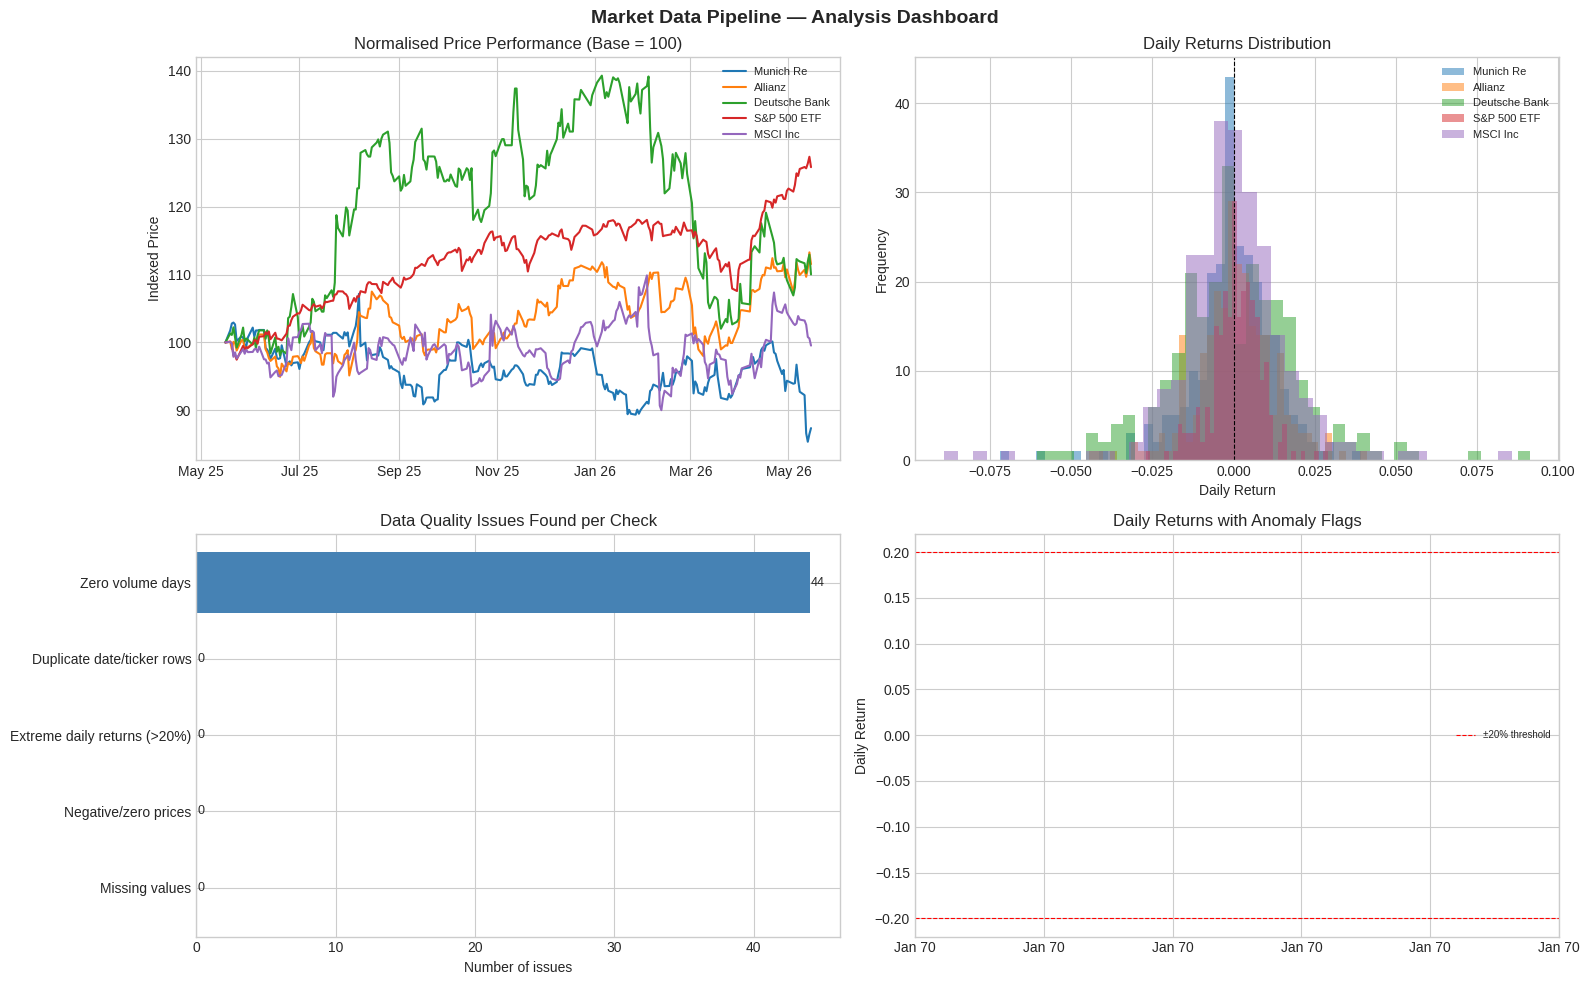

Dashboard saved as market_data_dashboard.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Market Data Pipeline — Analysis Dashboard', fontsize=14, fontweight='bold')

colors = plt.cm.tab10.colors

# Plot 1: Normalised price trends (base 100)
ax = axes[0, 0]
for i, (ticker, name) in enumerate(TICKERS.items()):
    subset = analysis_df[analysis_df['ticker'] == ticker].sort_values('date')
    if len(subset) > 0:
        normalised = subset['close_price'] / subset['close_price'].iloc[0] * 100
        ax.plot(subset['date'], normalised, label=name, color=colors[i], linewidth=1.5)
ax.set_title('Normalised Price Performance (Base = 100)')
ax.set_ylabel('Indexed Price')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

# Plot 2: Daily returns distribution
ax = axes[0, 1]
for i, (ticker, name) in enumerate(TICKERS.items()):
    subset = analysis_df[analysis_df['ticker'] == ticker]
    returns = subset['daily_return'].dropna()
    ax.hist(returns, bins=40, alpha=0.5, label=name, color=colors[i])
ax.set_title('Daily Returns Distribution')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Plot 3: Data quality report
ax = axes[1, 0]
bars = ax.barh(quality_report['check'], quality_report['issues_found'], color='steelblue')
ax.set_title('Data Quality Issues Found per Check')
ax.set_xlabel('Number of issues')
for bar, val in zip(bars, quality_report['issues_found']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

# Plot 4: Anomaly flags over time
ax = axes[1, 1]
anomalies = analysis_df[analysis_df['anomaly_flag'] == 1]
if len(anomalies) > 0:
    for i, (ticker, name) in enumerate(TICKERS.items()):
        subset = analysis_df[analysis_df['ticker'] == ticker].sort_values('date')
        ax.plot(subset['date'], subset['daily_return'], alpha=0.4,
                color=colors[i], linewidth=0.8)
        anom = anomalies[anomalies['ticker'] == ticker]
        ax.scatter(anom['date'], anom['daily_return'], color='red',
                   zorder=5, s=40, label=f"{name} anomaly" if len(anom) > 0 else None)
ax.axhline(0.20,  color='red', linestyle='--', linewidth=0.8, label='±20% threshold')
ax.axhline(-0.20, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Daily Returns with Anomaly Flags')
ax.set_ylabel('Daily Return')
ax.legend(fontsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.savefig('market_data_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as market_data_dashboard.png")

## Step 8: Summary statistics

In [16]:
summary = analysis_df.groupby('asset_name').agg(
    trading_days     = ('date', 'count'),
    latest_price     = ('close_price', 'last'),
    avg_daily_return = ('daily_return', 'mean'),
    volatility       = ('daily_return', 'std'),
    anomalies_flagged= ('anomaly_flag', 'sum'),
    data_quality_pct = ('anomaly_flag', lambda x: round((1 - x.mean()) * 100, 1))
).round(4)

print("=== Market Data Summary ===")
print(summary.to_string())
print(f"\nPipeline completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nFiles produced:")
print("   Azure Blob: processed/market_data_YYYYMMDD.csv")
print("   Azure Blob: reports/quality_report_YYYYMMDD.csv")
print("   Local: market_data_dashboard.png")

=== Market Data Summary ===
               trading_days  latest_price  avg_daily_return  volatility  anomalies_flagged  data_quality_pct
asset_name                                                                                                  
Allianz                 253        374.50            0.0005      0.0121                  0             100.0
Deutsche Bank           253         26.70            0.0006      0.0199                  0             100.0
MSCI Inc                251        561.72            0.0001      0.0175                  0             100.0
Munich Re               253        473.00           -0.0004      0.0133                  0             100.0
S&P 500 ETF             251        739.17            0.0009      0.0076                  0             100.0

Pipeline completed at: 2026-05-16 16:49:27

Files produced:
   Azure Blob: processed/market_data_YYYYMMDD.csv
   Azure Blob: reports/quality_report_YYYYMMDD.csv
   Local: market_data_dashboard.png
